In [5]:
import pandas as pd
import numpy as np

import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings("ignore")

In [6]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [7]:
stop_words = set(stopwords.words('english'))

stemmer = PorterStemmer()

lemmatizer = WordNetLemmatizer()

In [8]:
import zipfile

with zipfile.ZipFile("/content/archive.zip", "r") as zip_ref:
    zip_ref.extractall("/content/emotions")

In [9]:
train_df = pd.read_csv(
    "/content/emotions/train.txt",
    sep=";",
    header=None,
    names=["text", "emotion"]
)

val_df = pd.read_csv(
    "/content/emotions/val.txt",
    sep=";",
    header=None,
    names=["text", "emotion"]
)

test_df = pd.read_csv(
    "/content//emotions/test.txt",
    sep=";",
    header=None,
    names=["text", "emotion"]
)

In [10]:
print(train_df.head())

                                                text  emotion
0                            i didnt feel humiliated  sadness
1  i can go from feeling so hopeless to so damned...  sadness
2   im grabbing a minute to post i feel greedy wrong    anger
3  i am ever feeling nostalgic about the fireplac...     love
4                               i am feeling grouchy    anger


In [11]:
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (16000, 2)
Validation: (2000, 2)
Test: (2000, 2)


In [12]:
print(train_df.isnull().sum())
print(val_df.isnull().sum())
print(test_df.isnull().sum())

text       0
emotion    0
dtype: int64
text       0
emotion    0
dtype: int64
text       0
emotion    0
dtype: int64


In [13]:
print("Duplicate training rows:", train_df.duplicated().sum())

Duplicate training rows: 1


In [14]:
train_df = train_df.drop_duplicates()

In [15]:
print(train_df["emotion"].value_counts())

emotion
joy         5361
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


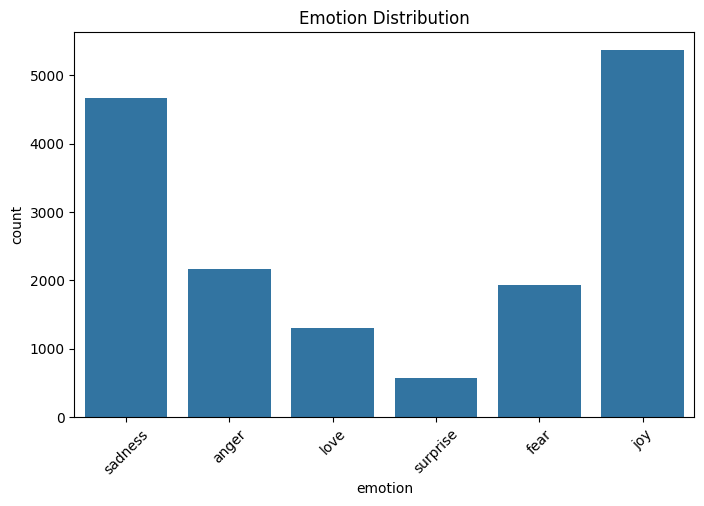

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=train_df,
    x="emotion"
)

plt.title("Emotion Distribution")
plt.xticks(rotation=45)
plt.show()

In [17]:
def preprocess_text(text):

    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # 3. Remove non-alphabetic characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 4. Tokenization
    words = text.split()

    # 5. Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    # 6. Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    # 7. Join words back
    return " ".join(words)

In [18]:
train_df["clean_text"] = train_df["text"].apply(preprocess_text)

val_df["clean_text"] = val_df["text"].apply(preprocess_text)

test_df["clean_text"] = test_df["text"].apply(preprocess_text)

In [19]:
train_df[["text", "clean_text"]].head(10)

,text,clean_text
0,i didnt feel humiliated,didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,go feeling hopeless damned hopeful around some...
2,im grabbing a minute to post i feel greedy wrong,im grabbing minute post feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,ever feeling nostalgic fireplace know still pr...
4,i am feeling grouchy,feeling grouchy
5,ive been feeling a little burdened lately wasn...,ive feeling little burdened lately wasnt sure
6,ive been taking or milligrams or times recomme...,ive taking milligram time recommended amount i...
7,i feel as confused about life as a teenager or...,feel confused life teenager jaded year old man
8,i have been with petronas for years i feel tha...,petronas year feel petronas performed well mad...
9,i feel romantic too,feel romantic


In [20]:
X_train = train_df["clean_text"]
y_train = train_df["emotion"]

X_val = val_df["clean_text"]
y_val = val_df["emotion"]

X_test = test_df["clean_text"]
y_test = test_df["emotion"]

In [21]:
bow_vectorizer = CountVectorizer()

X_train_bow = bow_vectorizer.fit_transform(X_train)

X_val_bow = bow_vectorizer.transform(X_val)

X_test_bow = bow_vectorizer.transform(X_test)

In [22]:
print(X_train_bow.shape)

(15999, 13464)


In [23]:
lr_bow = LogisticRegression(
    max_iter=2000
)

lr_bow.fit(
    X_train_bow,
    y_train
)

LogisticRegression(max_iter=2000)

In [24]:
y_pred = lr_bow.predict(X_test_bow)

In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       anger       0.88      0.88      0.88       275
        fear       0.85      0.84      0.84       224
         joy       0.91      0.93      0.92       695
        love       0.79      0.77      0.78       159
     sadness       0.93      0.94      0.94       581
    surprise       0.76      0.62      0.68        66

    accuracy                           0.89      2000
   macro avg       0.85      0.83      0.84      2000
weighted avg       0.89      0.89      0.89      2000



In [26]:
bow_ngram = CountVectorizer(
    ngram_range=(1, 2),
    min_df=2
)

In [27]:
X_train_bow_ngram = bow_ngram.fit_transform(X_train)

X_test_bow_ngram = bow_ngram.transform(X_test)

In [28]:
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)

X_val_tfidf = tfidf.transform(X_val)

X_test_tfidf = tfidf.transform(X_test)

In [29]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [30]:
lr_tfidf = LogisticRegression(
    max_iter=2000
)

lr_tfidf.fit(
    X_train_tfidf,
    y_train
)

y_pred_lr = lr_tfidf.predict(X_test_tfidf)

In [31]:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

       anger       0.88      0.83      0.86       275
        fear       0.88      0.80      0.84       224
         joy       0.85      0.96      0.90       695
        love       0.83      0.62      0.71       159
     sadness       0.90      0.93      0.91       581
    surprise       0.92      0.52      0.66        66

    accuracy                           0.87      2000
   macro avg       0.88      0.78      0.81      2000
weighted avg       0.87      0.87      0.87      2000



In [32]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train_tfidf,
    y_train
)

y_pred_dt = dt.predict(X_test_tfidf)

In [33]:
print(
    classification_report(
        y_test,
        y_pred_dt
    )
)

              precision    recall  f1-score   support

       anger       0.86      0.88      0.87       275
        fear       0.79      0.81      0.80       224
         joy       0.90      0.88      0.89       695
        love       0.73      0.77      0.75       159
     sadness       0.90      0.89      0.90       581
    surprise       0.60      0.61      0.60        66

    accuracy                           0.86      2000
   macro avg       0.80      0.81      0.80      2000
weighted avg       0.86      0.86      0.86      2000



In [34]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_tfidf,
    y_train
)

y_pred_rf = rf.predict(X_test_tfidf)

In [35]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

       anger       0.89      0.90      0.90       275
        fear       0.86      0.87      0.86       224
         joy       0.89      0.93      0.91       695
        love       0.79      0.70      0.74       159
     sadness       0.94      0.92      0.93       581
    surprise       0.70      0.59      0.64        66

    accuracy                           0.89      2000
   macro avg       0.84      0.82      0.83      2000
weighted avg       0.89      0.89      0.89      2000



In [36]:
def evaluate_model(model_name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="macro"
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="macro"
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="macro"
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": f1,
        "Weighted F1": weighted_f1
    }

In [37]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression - BoW",
        y_test,
        lr_bow.predict(X_test_bow)
    )
)

results.append(
    evaluate_model(
        "Logistic Regression - TF-IDF",
        y_test,
        lr_tfidf.predict(X_test_tfidf)
    )
)

results.append(
    evaluate_model(
        "Decision Tree - TF-IDF",
        y_test,
        dt.predict(X_test_tfidf)
    )
)

results.append(
    evaluate_model(
        "Random Forest - TF-IDF",
        y_test,
        rf.predict(X_test_tfidf)
    )
)

In [38]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    "Macro F1",
    ascending=False
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Logistic Regression - BoW,0.8930,0.854140,0.829382,0.840548,0.892021
3,Random Forest - TF-IDF,0.8865,0.842561,0.818283,0.829127,0.885196
1,Logistic Regression - TF-IDF,0.8725,0.877043,0.775743,0.813433,0.868321
2,Decision Tree - TF-IDF,0.8580,0.796760,0.805782,0.801138,0.858496


In [39]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "class_weight": [None, "balanced"]
}

In [40]:
grid_search = GridSearchCV(
    LogisticRegression(
        max_iter=2000
    ),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

grid_search.fit(
    X_train_tfidf,
    y_train
)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=2000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'class_weight': [None, 'balanced']},
             scoring='f1_macro')

In [41]:
rf_params = {
    "n_estimators": [100, 300],
    "max_depth": [None, 20, 40],
    "min_samples_split": [2, 5],
    "class_weight": [None, "balanced"]
}

In [43]:
rf_grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_params,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

rf_grid.fit(
    X_train_tfidf,
    y_train
)

GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'class_weight': [None, 'balanced'],
                         'max_depth': [None, 20, 40],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 300]},
             scoring='f1_macro')

In [44]:
print(rf_grid.best_params_)
print(rf_grid.best_score_)

{'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
0.8440652023300126


In [45]:
dt_params = {
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "class_weight": [None, "balanced"]
}

In [46]:
dt_grid = GridSearchCV(
    DecisionTreeClassifier(
        random_state=42
    ),
    param_grid=dt_params,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

dt_grid.fit(
    X_train_tfidf,
    y_train
)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': [None, 'balanced'],
                         'max_depth': [10, 20, 30, None],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5, 10]},
             scoring='f1_macro')

In [47]:
best_lr = grid_search.best_estimator_

best_rf = rf_grid.best_estimator_

best_dt = dt_grid.best_estimator_

In [48]:
pred_lr = best_lr.predict(X_test_tfidf)

pred_rf = best_rf.predict(X_test_tfidf)

pred_dt = best_dt.predict(X_test_tfidf)

In [49]:
tuned_results = []

tuned_results.append(
    evaluate_model(
        "Tuned Logistic Regression",
        y_test,
        pred_lr
    )
)

tuned_results.append(
    evaluate_model(
        "Tuned Random Forest",
        y_test,
        pred_rf
    )
)

tuned_results.append(
    evaluate_model(
        "Tuned Decision Tree",
        y_test,
        pred_dt
    )
)

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df.sort_values(
    "Macro F1",
    ascending=False
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Tuned Logistic Regression,0.8835,0.820850,0.880879,0.843636,0.886577
1,Tuned Random Forest,0.8795,0.816763,0.860322,0.834989,0.882117
2,Tuned Decision Tree,0.8620,0.797714,0.856182,0.822006,0.865008


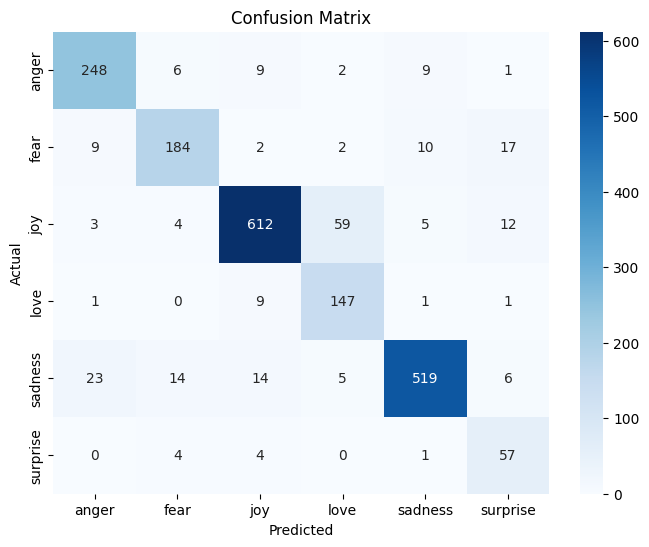

In [50]:
cm = confusion_matrix(
    y_test,
    pred_lr
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_lr.classes_,
    yticklabels=best_lr.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [51]:
print(
    classification_report(
        y_test,
        pred_lr
    )
)

              precision    recall  f1-score   support

       anger       0.87      0.90      0.89       275
        fear       0.87      0.82      0.84       224
         joy       0.94      0.88      0.91       695
        love       0.68      0.92      0.79       159
     sadness       0.95      0.89      0.92       581
    surprise       0.61      0.86      0.71        66

    accuracy                           0.88      2000
   macro avg       0.82      0.88      0.84      2000
weighted avg       0.90      0.88      0.89      2000



In [52]:
!pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 17.3 MB/s eta 0:00:00


In [53]:
from gensim.models import Word2Vec

In [55]:
train_tokens = [
    sentence.split()
    for sentence in X_train
]

In [56]:
w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=10
)

In [57]:
vector = w2v_model.wv["happy"]

print(vector)
print(vector.shape)

[-0.15433171  0.17800637 -0.03409635  0.29277068 -0.13100971 -0.37345335
  0.15556203  0.69842917 -0.31178325 -0.24334785  0.09400725 -0.34201244
 -0.00647161  0.13648753  0.06053666 -0.00911265  0.2087647  -0.05478196
  0.01741125 -0.63808304  0.26870447  0.06169597  0.3868642  -0.12033321
 -0.19945098  0.27895433  0.05477186 -0.24894792 -0.21584953  0.15212172
  0.28806123 -0.27663523  0.54885656 -0.26755798 -0.08036866  0.568636
  0.12764661 -0.00922564  0.01284613 -0.26748618  0.02655467 -0.31166983
 -0.05350677  0.04848395  0.19581886 -0.07217911 -0.12231462 -0.1654642
  0.09930606 -0.1231209   0.24772778  0.08702329  0.01747176 -0.14924507
 -0.08898022 -0.05617667  0.14253251 -0.12193181 -0.21019448  0.01260584
 -0.10827517  0.02537347 -0.03992278  0.01143544 -0.24310143  0.31772727
 -0.05957026  0.34722725 -0.5256692   0.33460912 -0.01525137  0.0568964
  0.20746116  0.18903244  0.2954984   0.09277414  0.08743621  0.14422089
 -0.35888588 -0.21245494 -0.23145306  0.28209123 -0.239

In [58]:
w2v_model.wv.most_similar("happy", topn=10)

[('stubborn', 0.8470330238342285),
 ('forever', 0.8465672135353088),
 ('yes', 0.8441677093505859),
 ('remind', 0.8402486443519592),
 ('ungrateful', 0.837959885597229),
 ('theyre', 0.8352683186531067),
 ('honestly', 0.8349148035049438),
 ('pray', 0.8341201543807983),
 ('known', 0.8317367434501648),
 ('enjoying', 0.8304219245910645)]

In [59]:
def sentence_vector(sentence, model):

    words = sentence.split()

    vectors = []

    for word in words:

        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

In [60]:
X_train_w2v = np.vstack([
    sentence_vector(text, w2v_model)
    for text in X_train
])

X_test_w2v = np.vstack([
    sentence_vector(text, w2v_model)
    for text in X_test
])

In [61]:
print(X_train_w2v.shape)

(15999, 100)


In [62]:
lr_w2v = LogisticRegression(
    max_iter=2000
)

lr_w2v.fit(
    X_train_w2v,
    y_train
)

pred_w2v = lr_w2v.predict(X_test_w2v)

In [63]:
evaluate_model(
    "Logistic Regression - Word2Vec",
    y_test,
    pred_w2v
)

{'Model': 'Logistic Regression - Word2Vec',
 'Accuracy': 0.48,
 'Macro Precision': 0.38323961361364134,
 'Macro Recall': 0.27764654421070983,
 'Macro F1': 0.26063394774114507,
 'Weighted F1': 0.4133547703832667}

In [64]:
final_results = []

# BoW
final_results.append(
    evaluate_model(
        "Logistic Regression - BoW",
        y_test,
        lr_bow.predict(X_test_bow)
    )
)

# BoW + Bigram
lr_bow_ngram = LogisticRegression(max_iter=2000)

lr_bow_ngram.fit(
    X_train_bow_ngram,
    y_train
)

final_results.append(
    evaluate_model(
        "Logistic Regression - BoW + Bigram",
        y_test,
        lr_bow_ngram.predict(X_test_bow_ngram)
    )
)

# TF-IDF
final_results.append(
    evaluate_model(
        "Logistic Regression - TF-IDF",
        y_test,
        lr_tfidf.predict(X_test_tfidf)
    )
)

# Word2Vec
final_results.append(
    evaluate_model(
        "Logistic Regression - Word2Vec",
        y_test,
        pred_w2v
    )
)

# Decision Tree
final_results.append(
    evaluate_model(
        "Decision Tree - TF-IDF",
        y_test,
        y_pred_dt
    )
)

# Random Forest
final_results.append(
    evaluate_model(
        "Random Forest - TF-IDF",
        y_test,
        y_pred_rf
    )
)

final_results_df = pd.DataFrame(final_results)

final_results_df = final_results_df.sort_values(
    "Macro F1",
    ascending=False
)

final_results_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,Logistic Regression - BoW + Bigram,0.8950,0.856854,0.829992,0.842132,0.893983
0,Logistic Regression - BoW,0.8930,0.854140,0.829382,0.840548,0.892021
5,Random Forest - TF-IDF,0.8865,0.842561,0.818283,0.829127,0.885196
2,Logistic Regression - TF-IDF,0.8725,0.877043,0.775743,0.813433,0.868321
4,Decision Tree - TF-IDF,0.8580,0.796760,0.805782,0.801138,0.858496
3,Logistic Regression - Word2Vec,0.4800,0.383240,0.277647,0.260634,0.413355


In [65]:
best_model = final_results_df.iloc[0]

print(best_model)

Model              Logistic Regression - BoW + Bigram
Accuracy                                        0.895
Macro Precision                              0.856854
Macro Recall                                 0.829992
Macro F1                                     0.842132
Weighted F1                                  0.893983
Name: 1, dtype: object
